In [2]:
import numpy as np
import pandas as pd
import statistics
from statsmodels import robust
from scipy import stats
from scipy.stats import t, sem
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [9]:
def asset_return(ticker_list): # function to get the asset return dataframe
    ticker_return = []
    for ticker in ticker_list.keys():
        ticker = yf.Ticker(ticker)
        ticker_df = ticker.history(period='max') # up to 100 years of historical data
        ticker_df['Return'] = ticker_df['Close'].pct_change().dropna(how='any')
        ticker_df.index = pd.Index(ticker_df.index.values.astype('M8[D]')) # make index yyyy-mm-dd
        ticker_return.append(ticker_df['Return'])
    
    ticker_return = pd.concat(ticker_return, axis=1).ffill().dropna(how='any')
    ticker_return.columns = ticker_list.values()
    
    ticker_return[ticker_return<-1] = -0.50 
    
    return ticker_return

def asset_return_normalized(ticker_df):
    return ticker_df.apply(lambda x: pd.Series((x-x.mean())/x.std()))

def asset_return_chi_square(ticker_df):
    # calculate chi-square: sum of squared standardized returns across all 5 assets
    ticker_df['chi'] = (ticker_df * ticker_df).sum(axis=1)
    return ticker_df

def asset_return_histogram(ticker_df):
    mu = 0
    sigma = 1
    n = 1000
    n_assets = ticker_df.shape[1] - 1  # number of asset columns (excludes 'chi')
    df_chi = n_assets - 1              # degrees of freedom = 5 - 1 = 4

    # histogram with standard normal distribution for 5 assets
    fig, axes = plt.subplots(ticker_df.shape[1], 1, figsize=(15, 15))
    plt.subplots_adjust(hspace = 0.5)
    for ax, ticker_df_column in zip(axes, ticker_df.columns[:-1]):
        ax_hist = sns.histplot(data=ticker_df[ticker_df_column], bins=250, ax=ax)
        ax2 = ax_hist.twinx()
        x = np.linspace(ticker_df[ticker_df_column].min(), ticker_df[ticker_df_column].max(), 1000)
        y = stats.norm.pdf(x, mu, sigma)                
        ax_norm = sns.lineplot(x=x, y=y, ax=ax2, color='red')
        ax.set_title('return histogram of '+ticker_df_column, fontsize=8)
        ax.set(ylabel = '')
        ax.set(xlabel = '')
        ax.set(xlim=(-10, 10))  # limit x-axis to handle crude oil outliers
        ax2.set(ylabel='')

    # histogram with chi-square distribution for chi-square data
    ax_hist = sns.histplot(data=ticker_df[ticker_df.columns[-1]], bins=1000, ax=axes[-1])
    ax_chi2 = ax_hist.twinx()
    x = np.linspace(0, 10, 1000)
    y = stats.chi2.pdf(x, df_chi)              
    ax_chi = sns.lineplot(x=x, y=y, ax=ax_chi2, color='red')
      
    axes[-1].set_title('Chi histogram of '+ticker_df.columns[-1], fontsize=8)
    axes[-1].set(ylabel = '')
    axes[-1].set(xlabel = '')
    axes[-1].set(xlim=(0, 10))
    ax_chi2.set(ylabel='')
    
    return(fig)

In [10]:
# list of assets
ticker_list = {'MSFT':'Microsoft', 
               'GOOGL':'Google',
               'TSLA':'Tesla', 
               'KO': 'CocaCola', 
               'NVDA': 'Nvidia'}

# dataframe of asset return
asset_return_df = asset_return(ticker_list)

# dataframe of normalized asset return
asset_return_norm_df = asset_return_normalized(asset_return_df)

# dataframe of Chi-square
asset_return_chi_square_df = asset_return_chi_square(asset_return_norm_df.copy())

In [11]:
asset_return_df

,Microsoft,Google,Tesla,CocaCola,Nvidia
2010-06-30,-0.012870,-0.020495,-0.002511,-0.004172,-0.025763
2010-07-01,0.006519,-0.012271,-0.078473,-0.001796,0.016651
2010-07-02,0.004750,-0.006689,-0.125683,0.000399,-0.012524
2010-07-06,0.023635,-0.001100,-0.160937,0.007593,-0.010732
2010-07-07,0.020151,0.032403,-0.019243,0.020622,0.048324
...,...,...,...,...,...
2026-03-18,-0.019078,-0.010389,-0.016255,-0.020753,-0.008410
2026-03-19,-0.007070,-0.001820,-0.031774,-0.005528,-0.010200
2026-03-20,-0.018380,-0.019959,-0.032448,-0.010589,-0.032818
2026-03-23,0.002959,0.003522,0.035031,0.004816,0.017024


In [12]:
asset_return_norm_df

,Microsoft,Google,Tesla,CocaCola,Nvidia
2010-06-30,-0.851734,-1.234212,-0.125565,-0.431508,-0.969955
2010-07-01,0.347238,-0.761399,-2.221720,-0.209864,0.507840
2010-07-02,0.237878,-0.440487,-3.524492,-0.005139,-0.508682
2010-07-06,1.405738,-0.119098,-4.497339,0.665693,-0.446221
2010-07-07,1.190262,1.807091,-0.587272,1.880835,1.611396
...,...,...,...,...,...
2026-03-18,-1.235648,-0.653161,-0.504809,-1.977773,-0.365325
2026-03-19,-0.493082,-0.160522,-0.933053,-0.557971,-0.427683
2026-03-20,-1.192446,-1.203401,-0.951667,-1.029915,-1.215765
2026-03-23,0.127125,0.146586,0.910422,0.406750,0.520838


In [13]:
asset_return_chi_square_df

,Microsoft,Google,Tesla,CocaCola,Nvidia,chi
2010-06-30,-0.851734,-1.234212,-0.125565,-0.431508,-0.969955,3.391507
2010-07-01,0.347238,-0.761399,-2.221720,-0.209864,0.507840,5.938289
2010-07-02,0.237878,-0.440487,-3.524492,-0.005139,-0.508682,12.931443
2010-07-06,1.405738,-0.119098,-4.497339,0.665693,-0.446221,22.858608
2010-07-07,1.190262,1.807091,-0.587272,1.880835,1.611396,11.161330
...,...,...,...,...,...,...
2026-03-18,-1.235648,-0.653161,-0.504809,-1.977773,-0.365325,6.253328
2026-03-19,-0.493082,-0.160522,-0.933053,-0.557971,-0.427683,1.633730
2026-03-20,-1.192446,-1.203401,-0.951667,-1.029915,-1.215765,6.314581
2026-03-23,0.127125,0.146586,0.910422,0.406750,0.520838,1.303235


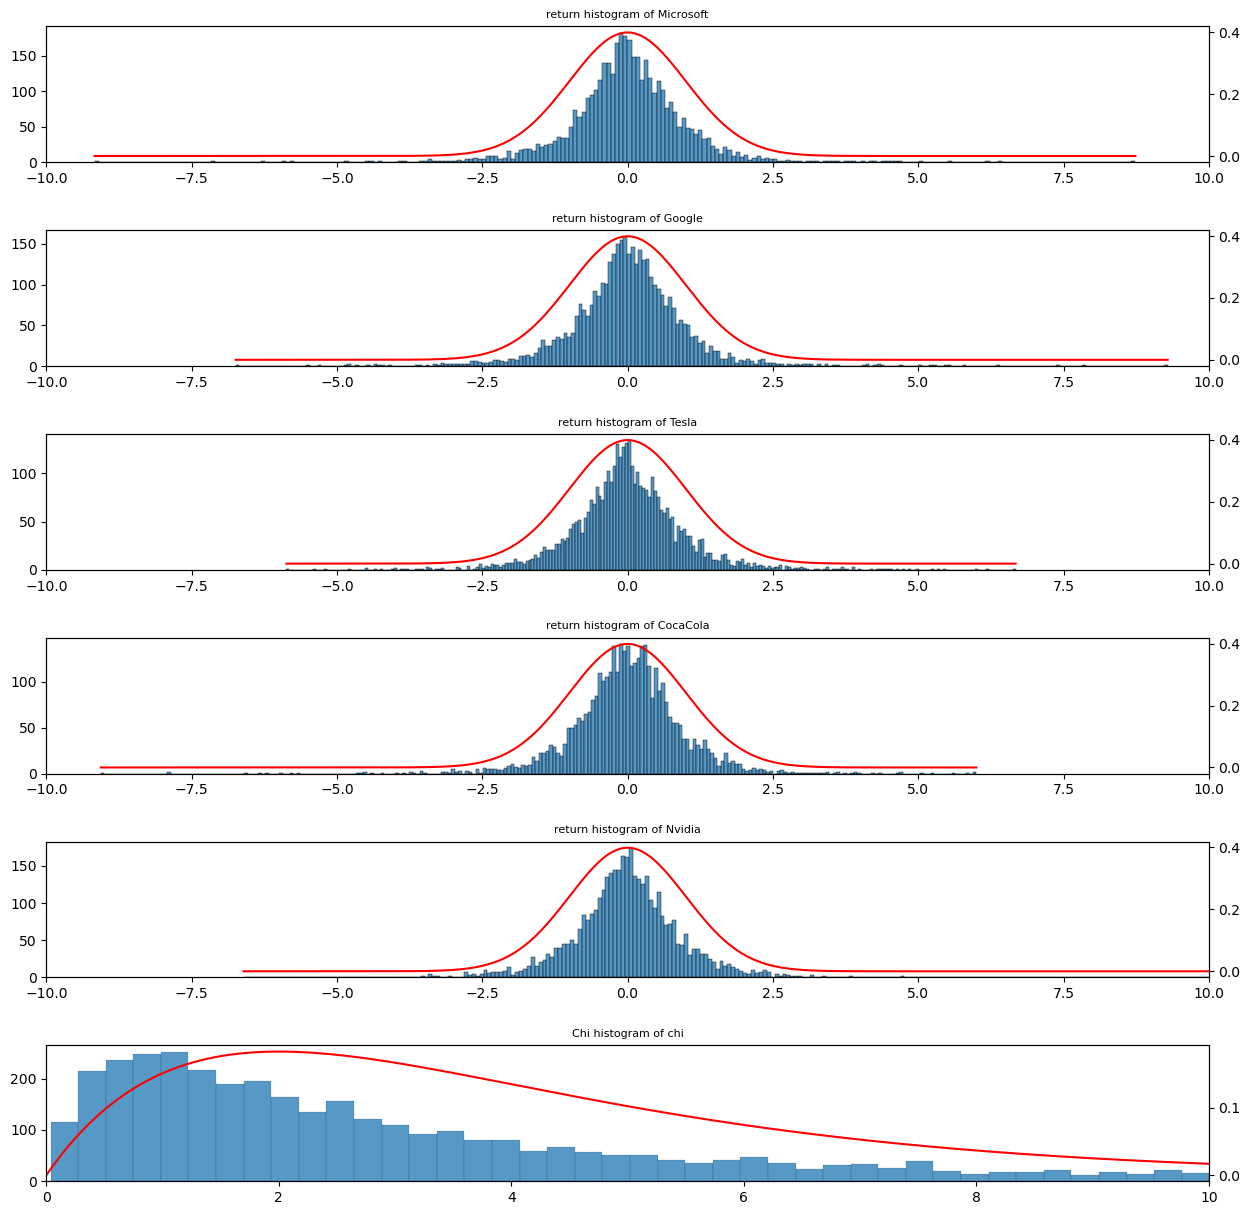

In [14]:
asset_ret_hist = asset_return_histogram(asset_return_chi_square_df)